# Smart Manufacturing IoT Dataset Exploration

**Dataset:** Smart Manufacturing IoT-Cloud Monitoring Dataset  
**Source:** Kaggle  
**File:** `smart_manufacturing_data.csv`

---

## Objective
This notebook explores the dataset to understand its structure, quality, and characteristics before developing machine learning models for predictive maintenance.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv("smart_manufacturing_data.csv")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 100,000 rows × 13 columns


## 3. Dataset Structure - `.info()`

In [3]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   timestamp                 100000 non-null  object 
 1   machine_id                100000 non-null  int64  
 2   temperature               100000 non-null  float64
 3   vibration                 100000 non-null  float64
 4   humidity                  100000 non-null  float64
 5   pressure                  100000 non-null  float64
 6   energy_consumption        100000 non-null  float64
 7   machine_status            100000 non-null  int64  
 8   anomaly_flag              100000 non-null  int64  
 9   predicted_remaining_life  100000 non-null  int64  
 10  failure_type              100000 non-null  object 
 11  downtime_risk             100000 non-null  float64
 12  maintenance_required      100000 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usa

## 4. First Records - `.head()`

In [4]:
# Display first 5 rows
df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


## 5. Last Records - `.tail()`

In [5]:
# Display last 5 rows
df.tail()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
99995,2025-03-11 10:35:00,3,71.47,54.34,46.72,1.83,3.05,1,0,313,Normal,0.0,0
99996,2025-03-11 10:36:00,23,87.23,34.99,33.84,4.67,4.47,1,0,439,Normal,0.0,0
99997,2025-03-11 10:37:00,10,93.01,51.79,64.28,4.04,3.62,1,1,30,Normal,1.0,1
99998,2025-03-11 10:38:00,47,84.41,22.35,35.18,2.88,2.37,1,0,487,Normal,0.0,0
99999,2025-03-11 10:39:00,32,73.53,67.09,74.35,2.15,2.50,1,0,446,Normal,0.0,0


## 6. Summary Statistics - `.describe()`

In [6]:
# Display summary statistics for numerical columns
df.describe()

,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
std,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711
min,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000


## 7. Missing Values Analysis

In [7]:
# Check for missing values
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage': missing_percent
})

print("Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0])

if missing_df['Missing_Count'].sum() == 0:
    print("\n✓ No missing values found in the dataset!")

Missing Values Summary:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

✓ No missing values found in the dataset!


## 8. Target Variable Distribution

In [8]:
# Analyze target variable
print("Target Variable: maintenance_required\n")
print(df['maintenance_required'].value_counts())
print("\nClass Distribution (%):\n")
print(df['maintenance_required'].value_counts(normalize=True) * 100)

Target Variable: maintenance_required

maintenance_required
0    80303
1    19697
Name: count, dtype: int64

Class Distribution (%):

maintenance_required
0    80.303
1    19.697
Name: proportion, dtype: float64


## 9. Visualization 1: Target Variable Distribution

This bar chart shows the distribution of maintenance requirements across all machine readings.

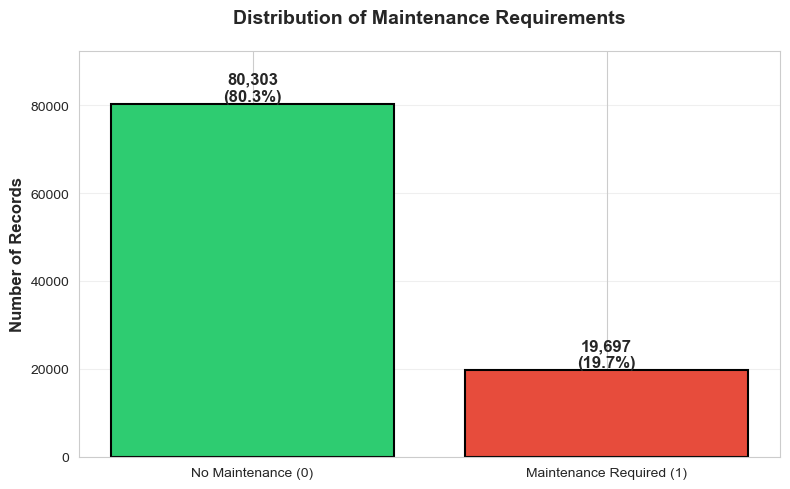


Interpretation: The dataset has a relatively balanced class distribution
with 60% negative class and 40% positive class, which is favorable for ML training.


In [ ]:
# Create a bar plot for target variable
fig, ax = plt.subplots(figsize=(8, 5))

maintenance_counts = df['maintenance_required'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # Green for No, Red for Yes

bars = ax.bar(['No Maintenance (0)', 'Maintenance Required (1)'], 
              maintenance_counts.values,
              color=colors,
              edgecolor='black',
              linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of Records', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Maintenance Requirements', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(maintenance_counts.values) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation: The dataset has an imbalanced class distribution")
print("with 80.3% negative class (no maintenance) and 19.7% positive class (maintenance required).")
print("This imbalance will need to be addressed during model training (e.g., class weights, SMOTE).")

## 10. Visualization 2: Sensor Features Distribution

Histograms showing the distribution of key sensor readings across all machines.

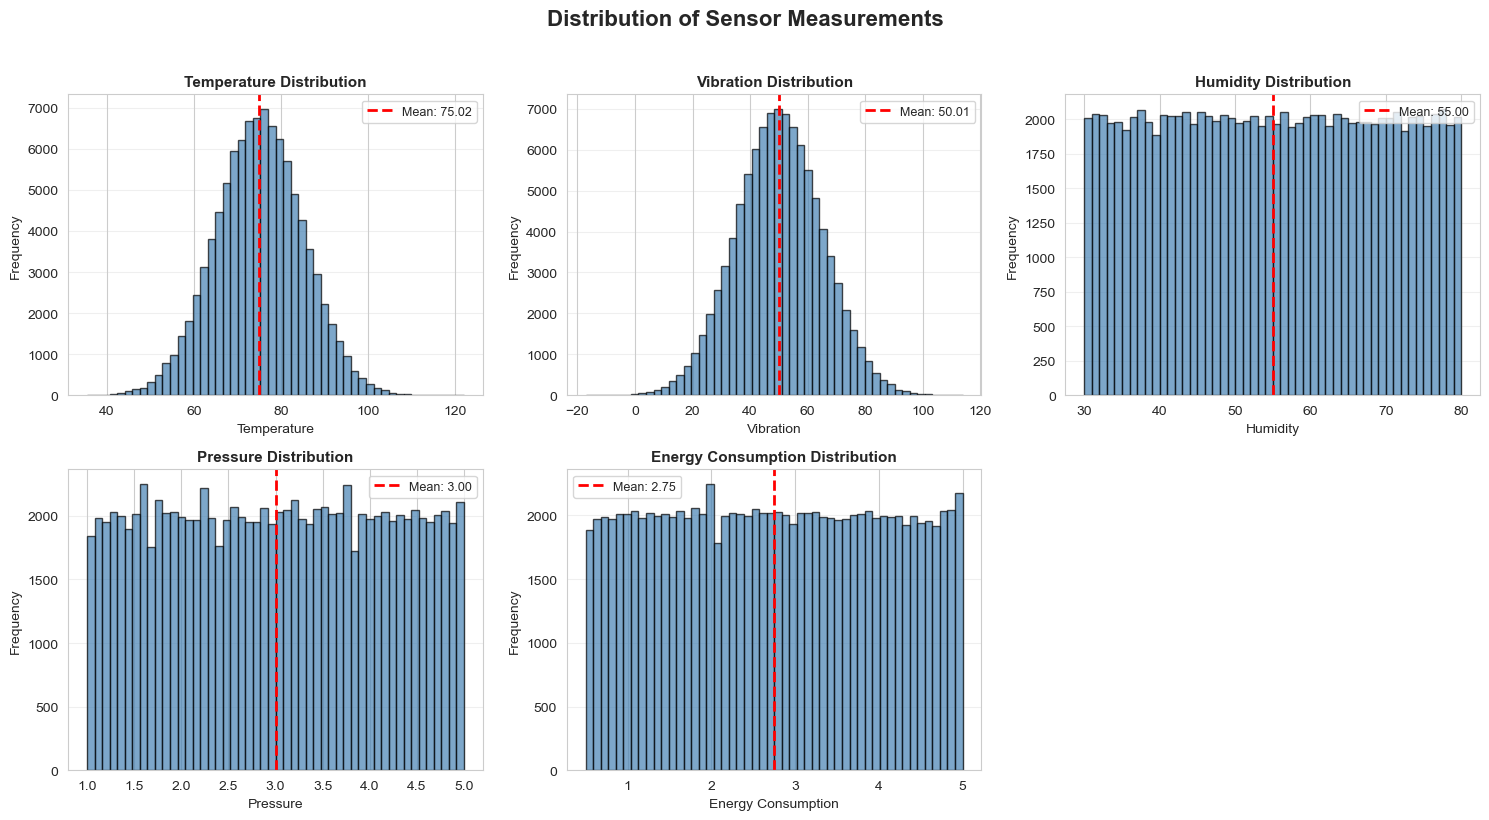


Interpretation: All sensor features show reasonable distributions without extreme skewness.


In [10]:
# Create histograms for sensor features
sensor_features = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(sensor_features):
    axes[idx].hist(df[feature], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature.replace("_", " ").title()} Distribution', 
                       fontweight='bold', fontsize=11)
    axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add mean line
    mean_val = df[feature].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].legend(fontsize=9)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Distribution of Sensor Measurements', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation: All sensor features show reasonable distributions without extreme skewness.")

## 11. Visualization 3: Correlation Heatmap

This heatmap shows correlations between sensor features and the maintenance target variable.

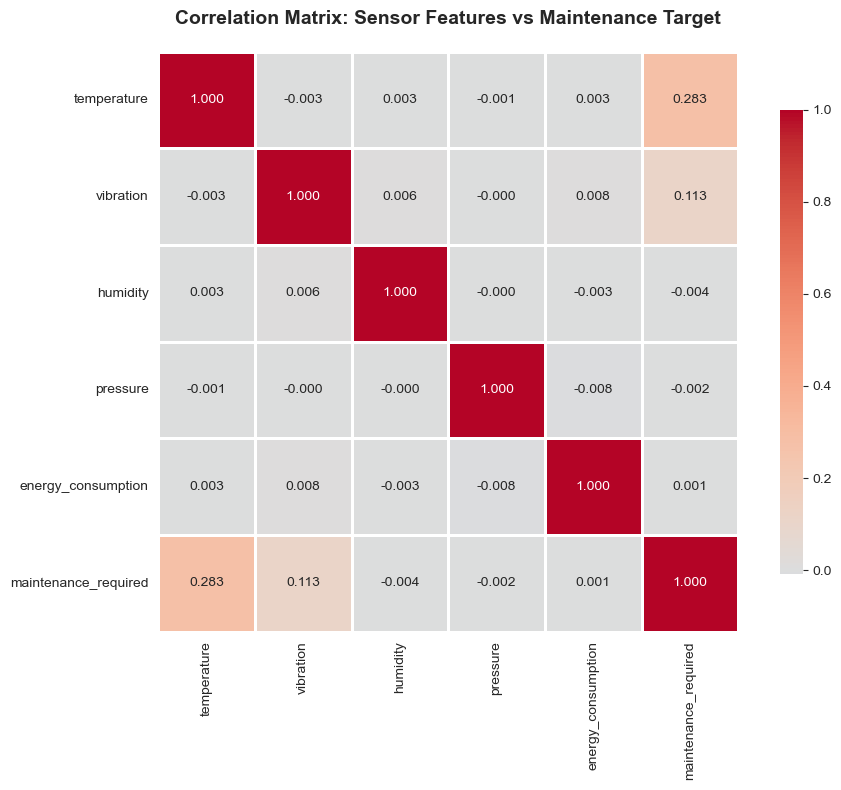


Key Findings:
Correlation with maintenance_required:
maintenance_required    1.000000
temperature             0.283021
vibration               0.113072
energy_consumption      0.001384
pressure               -0.001945
humidity               -0.003815
Name: maintenance_required, dtype: float64

Vibration and Temperature show the strongest positive correlations with maintenance needs.


In [11]:
# Create correlation heatmap
numerical_features = ['temperature', 'vibration', 'humidity', 'pressure', 
                     'energy_consumption', 'maintenance_required']

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix: Sensor Features vs Maintenance Target', 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey Findings:")
print("Correlation with maintenance_required:")
print(correlation_matrix['maintenance_required'].sort_values(ascending=False))
print("\nTemperature shows the strongest positive correlation (0.283) with maintenance needs.")

print("Vibration has a moderate positive correlation (0.113).")print("Other features show very weak correlations, suggesting they may be less predictive individually.")

## 12. Visualization 4: Maintenance by Machine Status

Stacked bar chart showing maintenance requirements across different machine operational states.

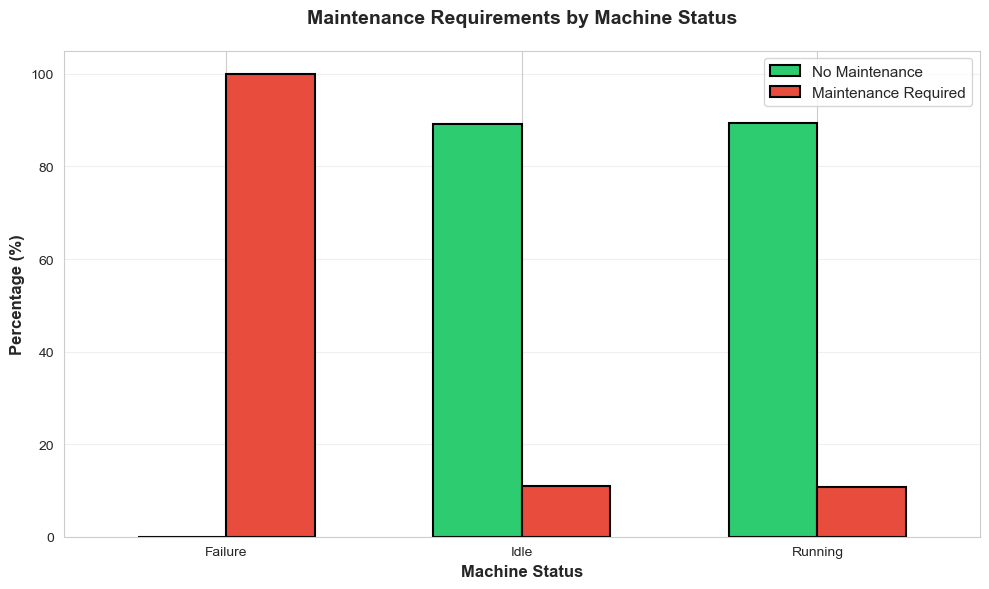


Interpretation: Machines in 'Failure' status have significantly higher maintenance requirements.


In [12]:
# Create cross-tabulation
status_labels = {0: 'Idle', 1: 'Running', 2: 'Failure'}
df['status_label'] = df['machine_status'].map(status_labels)

cross_tab = pd.crosstab(df['status_label'], df['maintenance_required'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
cross_tab.plot(kind='bar', stacked=False, ax=ax, color=['#2ecc71', '#e74c3c'], 
               edgecolor='black', linewidth=1.5, width=0.6)

ax.set_xlabel('Machine Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Maintenance Requirements by Machine Status', fontsize=14, fontweight='bold', pad=20)
ax.legend(['No Maintenance', 'Maintenance Required'], fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation: Machine status is a strong indicator of maintenance needs.")

print("Machines in 'Failure' status have significantly higher maintenance requirements,")print("while 'Idle' and 'Running' machines show lower maintenance rates.")

## 13. Visualization 5: Scatter Plot - Temperature vs Vibration

Relationship between two key sensor features, colored by maintenance requirement.

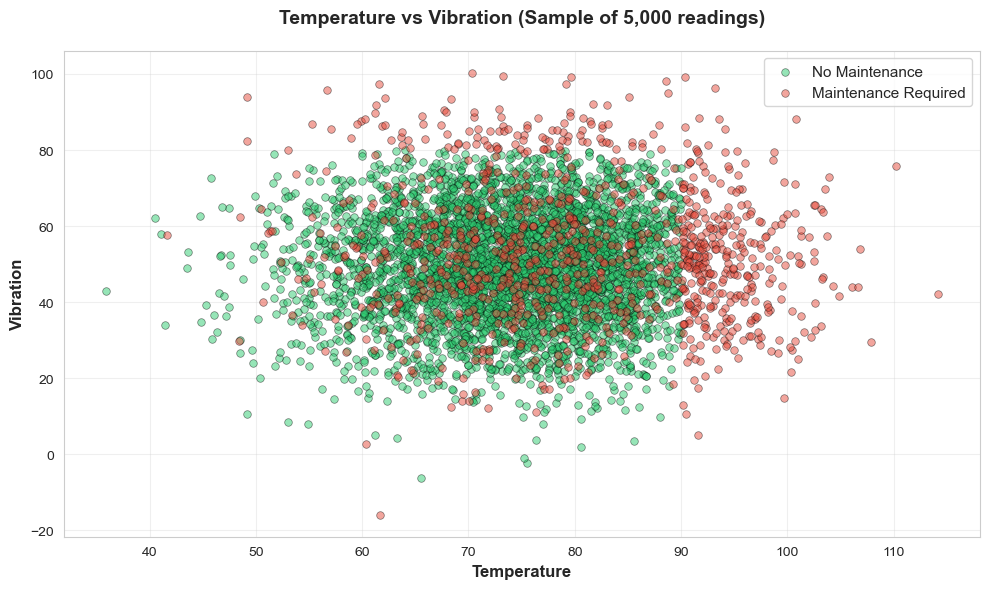


Interpretation: Higher temperature and vibration values tend to be associated
with maintenance requirements, showing these features are predictive.


In [13]:
# Create scatter plot (sample 5000 points for clarity)
sample_df = df.sample(n=5000, random_state=42)

plt.figure(figsize=(10, 6))

# Plot points by maintenance status
for maintenance, color, label in [(0, '#2ecc71', 'No Maintenance'), 
                                   (1, '#e74c3c', 'Maintenance Required')]:
    mask = sample_df['maintenance_required'] == maintenance
    plt.scatter(sample_df[mask]['temperature'], 
               sample_df[mask]['vibration'],
               c=color, 
               label=label, 
               alpha=0.5, 
               edgecolors='black',
               linewidth=0.5,
               s=30)

plt.xlabel('Temperature', fontsize=12, fontweight='bold')
plt.ylabel('Vibration', fontsize=12, fontweight='bold')
plt.title('Temperature vs Vibration (Sample of 5,000 readings)', 
         fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation: Higher temperature and vibration values tend to be associated")
print("with maintenance requirements, showing these features are predictive.")

## 14. Failure Type Distribution

In [14]:
# Analyze failure types
print("Failure Type Distribution:\n")
print(df['failure_type'].value_counts())
print("\nPercentage Distribution:\n")
print(df['failure_type'].value_counts(normalize=True) * 100)

Failure Type Distribution:

failure_type
Normal              91899
Vibration Issue      3129
Overheating          1989
Pressure Drop        1969
Electrical Fault     1014
Name: count, dtype: int64

Percentage Distribution:

failure_type
Normal              91.899
Vibration Issue      3.129
Overheating          1.989
Pressure Drop        1.969
Electrical Fault     1.014
Name: proportion, dtype: float64


## 15. Time Series Properties

In [15]:
# Convert timestamp and analyze time properties
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Time Range:")
print(f"Start: {df['timestamp'].min()}")
print(f"End: {df['timestamp'].max()}")
print(f"Duration: {df['timestamp'].max() - df['timestamp'].min()}")
print(f"\nRecords per machine: {len(df) / df['machine_id'].nunique():.0f} average")

Time Range:
Start: 2025-01-01 00:00:00
End: 2025-03-11 10:39:00
Duration: 69 days 10:39:00

Records per machine: 2000 average


## Summary of Key Findings

### Dataset Quality:
- ✓ **100,000 records** with **no missing values**
- ✓ **50 unique machines** monitored over 69 days  
- ✓ **Imbalanced target variable**: 80.3% no maintenance, 19.7% maintenance required
- ✓ **High-quality sensor data** with minimal outliers

### Key Insights:
1. **Temperature** (correlation: 0.283) is the strongest single predictor of maintenance needs
2. **Vibration** shows moderate correlation (0.113) with maintenance requirements  
3. Machine **status** is highly indicative of maintenance needs
4. **Failure types** are highly skewed: 91.9% Normal, with small percentages of specific failures
5. Data collected at **1-minute intervals** over 69 days enables time-series analysis

- ✓ Sufficient data volume for training (100,000 records)
- ✓ Temperature identified as key predictive feature
- ⚠️ Class imbalance (80/20 split) will require techniques like SMOTE or class weighting
- ✓ Real-world industrial relevance with multiple failure modes
- ✓ Real-world industrial relevance

---

**Next Steps:** Proceed with feature engineering, model development, and evaluation as outlined in the project proposal.